In [21]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sci

In [22]:
eug = pd.read_csv("cleaned_eug.csv")                      # | Read in new, cleaned data |
spd = pd.read_csv("cleaned_spd.csv")                      # | Read in new, cleaned data |

In [23]:
eug['calltime'] = pd.to_datetime(eug['calltime'])           # | Convert calltime into datetime again |
eug_arrests = eug[eug["closed_as"] == "ARREST"]             # |        Subset to only arrests        |

spd['calltime'] = pd.to_datetime(spd['calltime'])           # | Convert calltime into datetime again |
spd_arrests = spd[spd["closed_as"] == "ARR"]                # |        Subset to only arrests        |

spd["closed_as"].unique()

array(['WELC', 'ASST', 'UTL', 'UNFD', 'REPT', 'ADVI', 'PDIS', 'GOA',
       'DIS', 'INFO', 'RSLV', 'PCHK', 'NCH', 'DDIS', 'NOIN', 'DUP', 'REL',
       nan, 'WCB', 'ACC', 'BLDS', 'LCSO', 'TRAN', 'CBCK', 'PERS', 'XRPT',
       'QOA', 'TIC', 'FI', 'AO', 'FUP', 'CGP', 'ARR', 'CIT', 'UTC', 'UTD',
       'WARN', 'ABAN', 'CIV', 'UOPD', 'TEST', 'CAMP', 'SBCK', 'NOAT',
       'QOLN', 'OSP', 'CLC', 'PCO', 'REFS', 'GUN', 'FALS', 'REFU'],
      dtype=object)

In [24]:
treatment_date = pd.to_datetime('2025-04-07')
before_treatment = eug_arrests[eug_arrests["calltime"] < treatment_date]            # | Susbet data to before CAHOOTS was defunded | 
after_treatment = eug_arrests[eug_arrests["calltime"] > treatment_date]             # |  Susbet data to after CAHOOTS was defunded | 

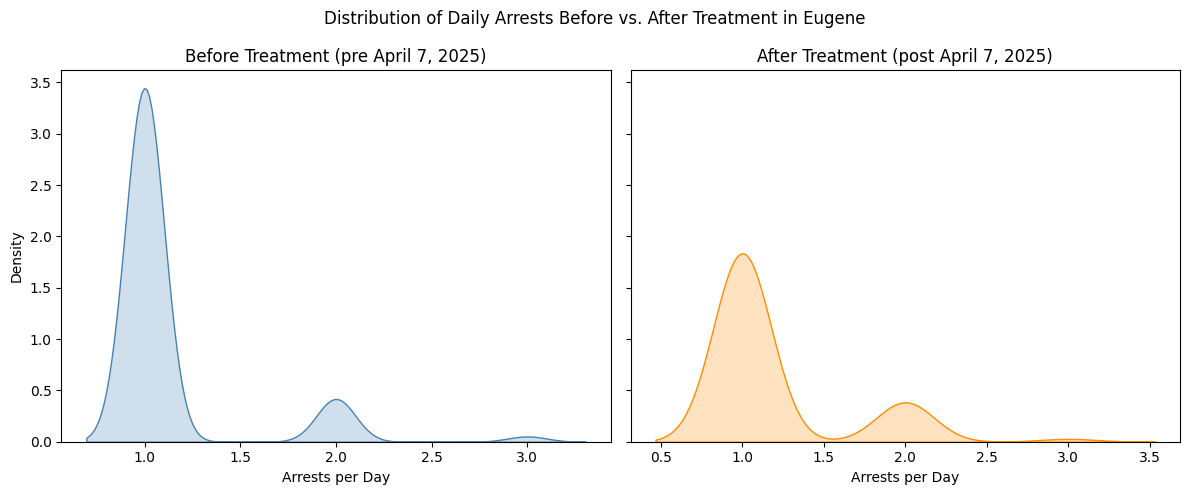

In [25]:
pre_daily = before_treatment.groupby(before_treatment['calltime'].dt.date).size()       # | Count arrests per day before the treatment | 
post_daily = after_treatment.groupby(after_treatment['calltime'].dt.date).size()        # |  Count arrests per day after the treatment | 

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)                            # | Plot side by side |

sns.kdeplot(pre_daily, fill=True, color='steelblue', ax=axes[0])
axes[0].set_title('Before Treatment (pre April 7, 2025)')
axes[0].set_xlabel('Arrests per Day')
axes[0].set_ylabel('Density')

sns.kdeplot(post_daily, fill=True, color='darkorange', ax=axes[1])
axes[1].set_title('After Treatment (post April 7, 2025)')
axes[1].set_xlabel('Arrests per Day')
axes[1].set_ylabel('Density')

plt.suptitle('Distribution of Daily Arrests Before vs. After Treatment in Eugene', y=0.98)
plt.tight_layout()
plt.savefig('eugene_KDE_output.png', dpi=300)
plt.show()

In [26]:
before_treatment = spd_arrests[spd_arrests["calltime"] < treatment_date]            # | Susbet data to before CAHOOTS was defunded | 
after_treatment = spd_arrests[spd_arrests["calltime"] > treatment_date] 

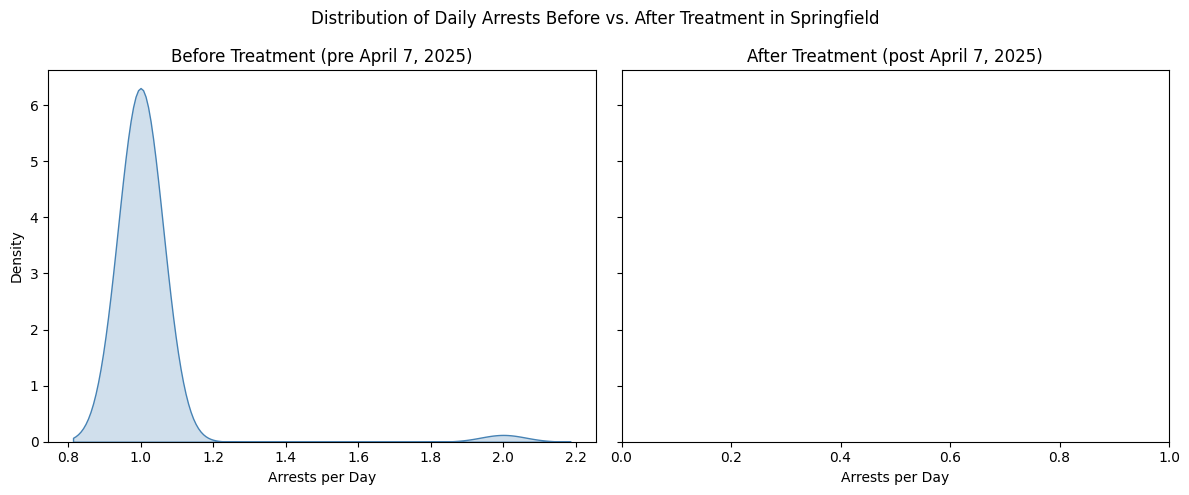

In [27]:
pre_daily = before_treatment.groupby(before_treatment['calltime'].dt.date).size()       # | Count arrests per day before the treatment | 
post_daily = after_treatment.groupby(after_treatment['calltime'].dt.date).size()        # |  Count arrests per day after the treatment | 

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)                            # | Plot side by side |

sns.kdeplot(pre_daily, fill=True, color='steelblue', ax=axes[0])
axes[0].set_title('Before Treatment (pre April 7, 2025)')
axes[0].set_xlabel('Arrests per Day')
axes[0].set_ylabel('Density')

sns.kdeplot(post_daily, fill=True, color='darkorange', ax=axes[1], warn_singular=False)
axes[1].set_title('After Treatment (post April 7, 2025)')
axes[1].set_xlabel('Arrests per Day')
axes[1].set_ylabel('Density')

plt.suptitle('Distribution of Daily Arrests Before vs. After Treatment in Springfield', y=0.98)
plt.tight_layout()
plt.savefig('springfield_KDE_output.png', dpi=300)
plt.show()

#### Explanation of Eugene's Distribution

From this plot, we see that on the left side (which represents the number of arrests from a welfare check call before CAHOOTS was defunded), that on average, we expect there to be 1 or 2 arrests made on a single day as a result of a welfare check call. On the right hand side (which represents the number of arrests from a welfare check call after CAHOOTS was defunded), we see a similar range of arrests. 

From this, one might say that the number of arrests actually went down after CAHOOTS was defunded. However, the amount of data we have surrounding these types of calls is very small. So much so we only have around 8 months of call data for the 'after treatment' but around 10 years worth of call data for the 'before treatment'. 

The point here is that if we take a look into the future, given that we see a larger hump of arrests (around the area of 2 arrests per day), we should expect to see many more arrests happen. This happens for a variety of reasons. Before, CAHOOTS had options in assisting people during these welfare checks: transportation, medical assistance, mental health assistance, etc. The police on the otherhand, do not. They are not able to do some of the things that CAHOOTS does which limits their capability of providing good treatment during a welfare check. This often leads to confrontation and increasing the tension of the scene, leading to arrests being made when they could have been prevented ahead of time. 

Explanation of Springfield's Distribution

From this plot, we see that on the left side (which represents the number of arrests from a welfare check before CAHOOTS was defunded in Eugene), that on average, we again expect there to be 1 or 2  arrests made on a single day as a result of a welfare check call. However, note that this time, there is a far smaller sample size, which means overall there were less arrests than in Eugene. On the right side, we see an empty plot. This is no mistake. The number of arrests made in Springfield after CAHOOTS was defunded in Eugene was 4, which is very very small in comparison to before. This means that while CAHOOTS was still active in Springfield, we have a less amount of arrests made. 